Max flow = 150


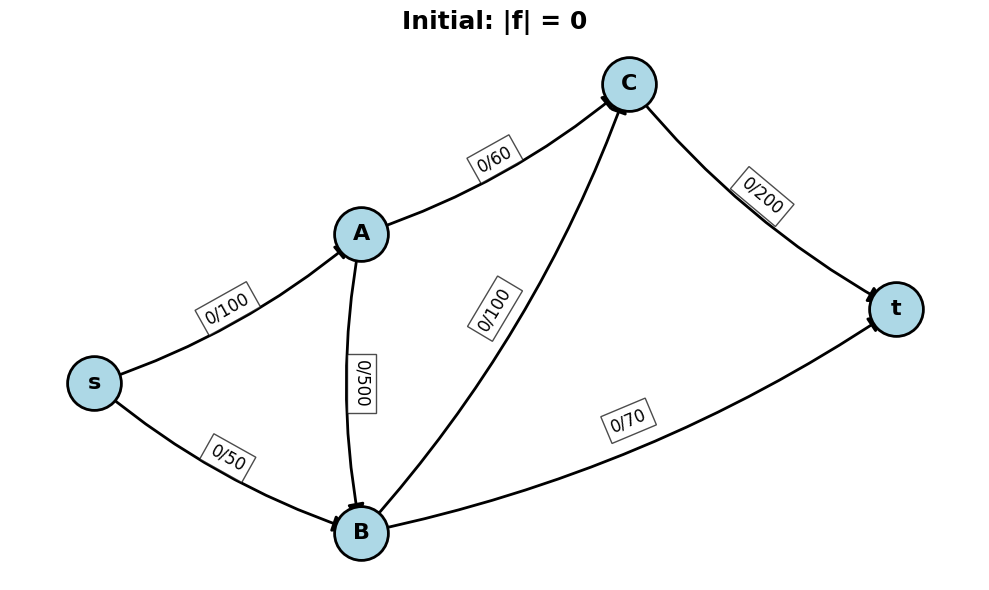

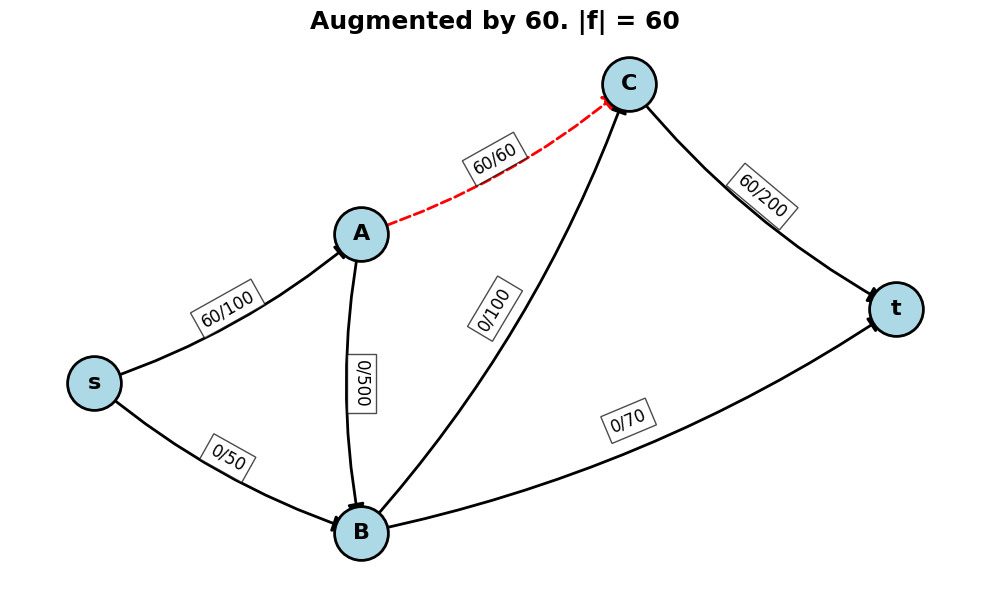

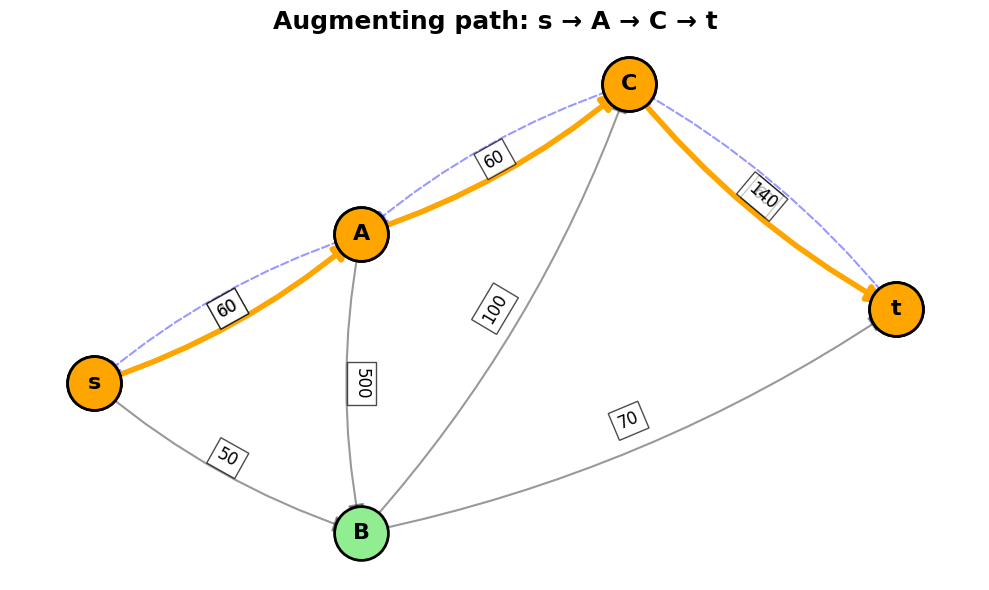

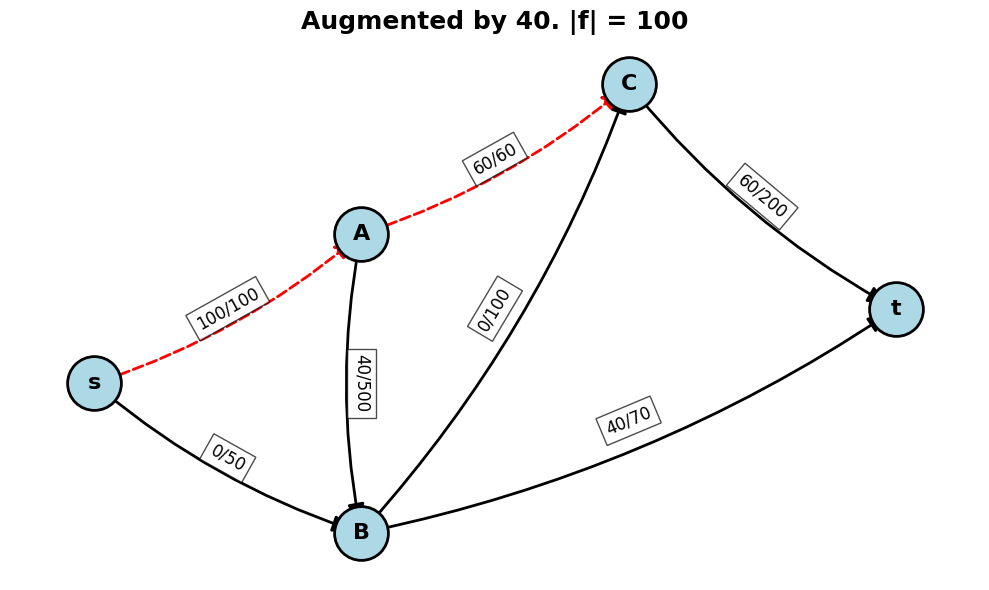

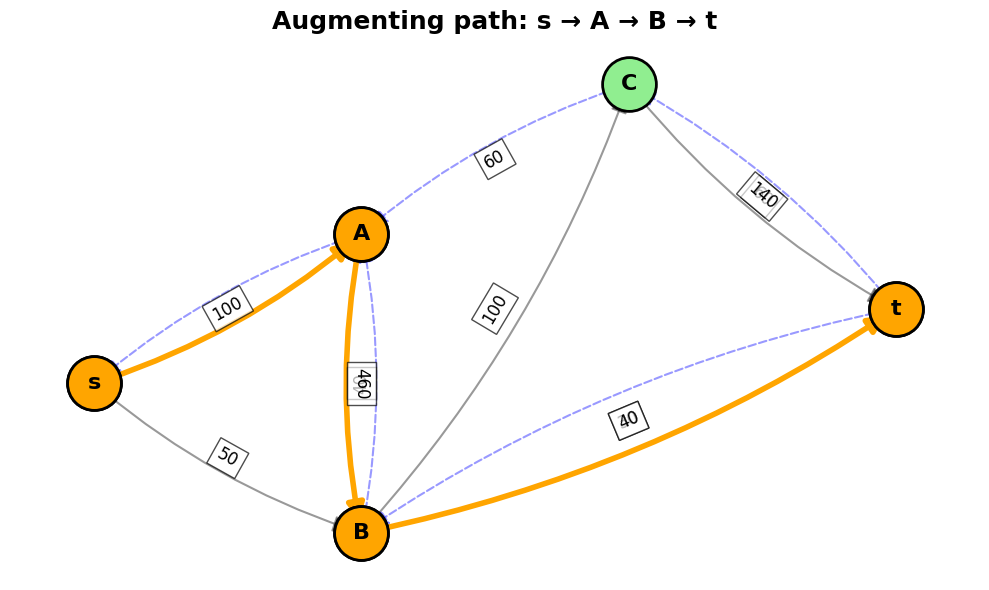

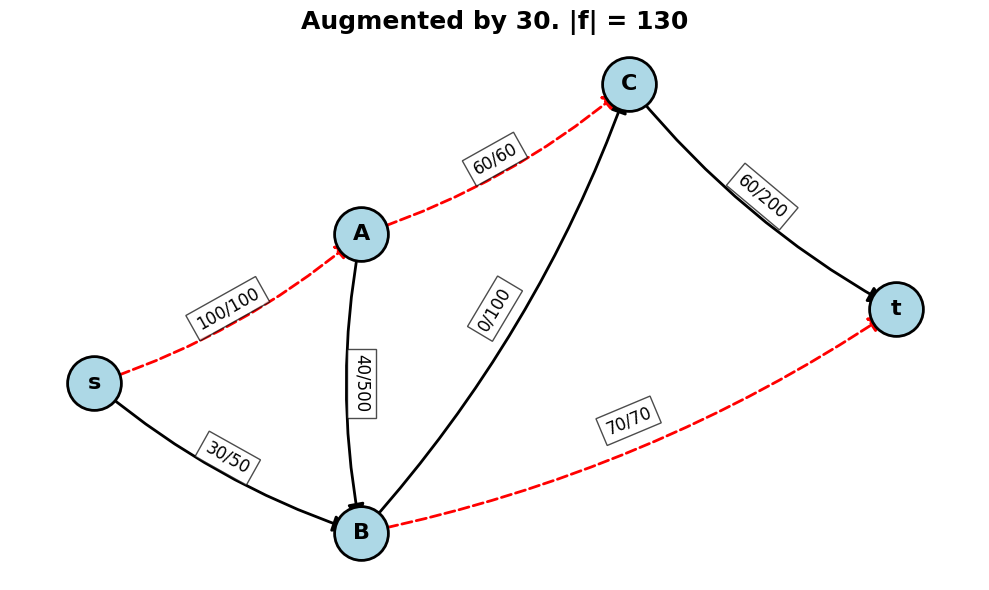

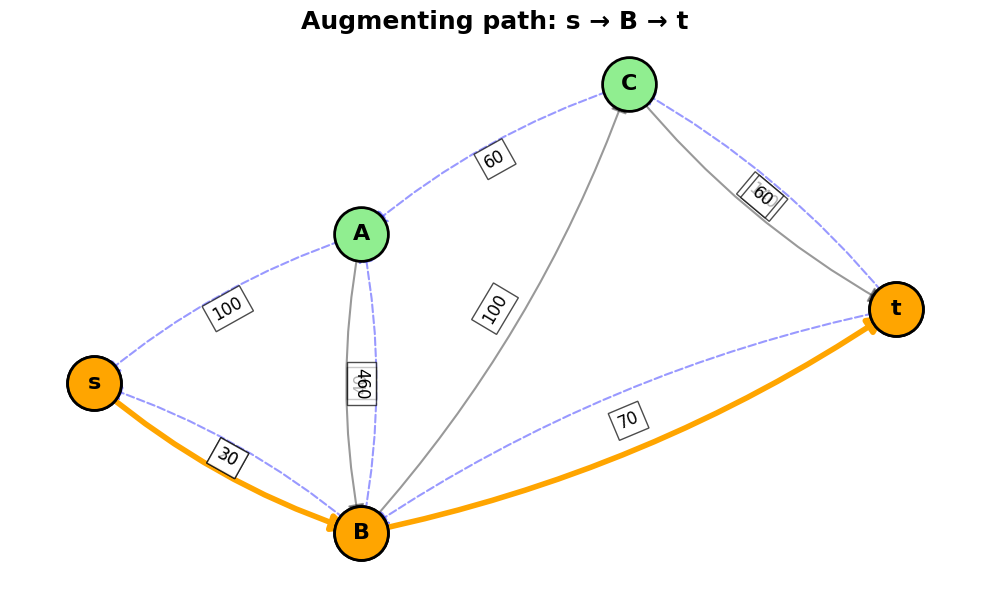

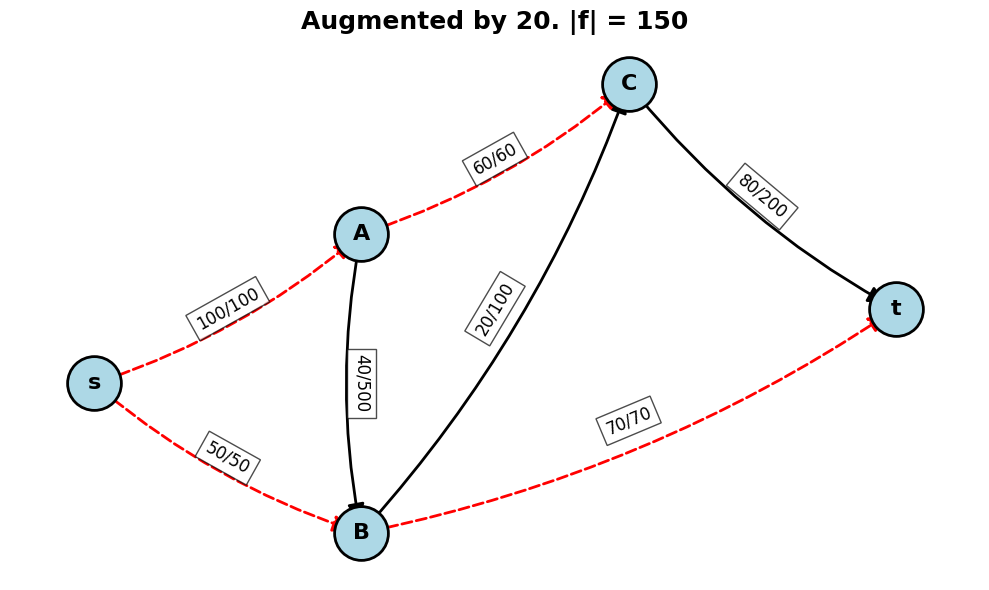

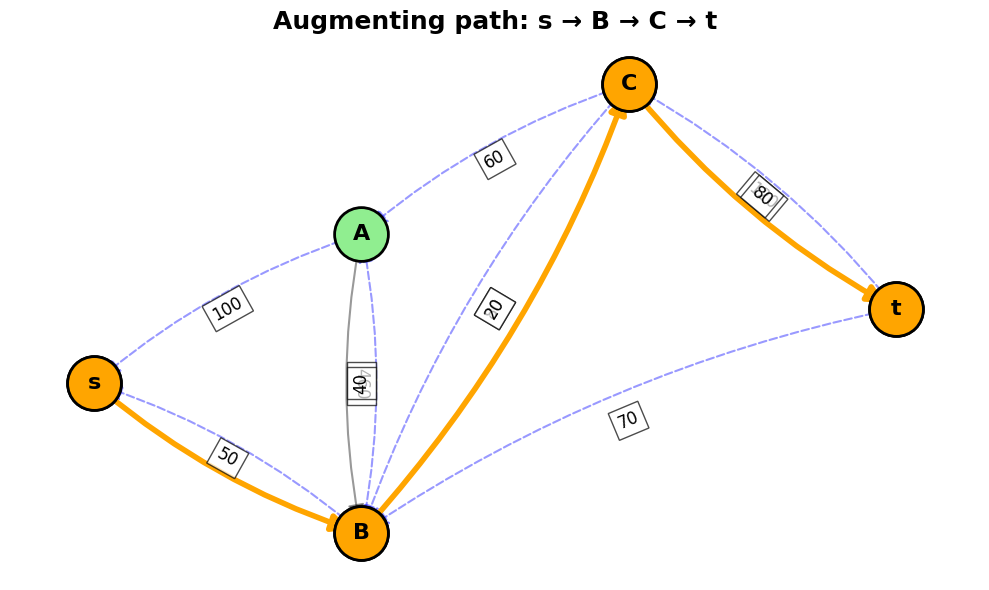

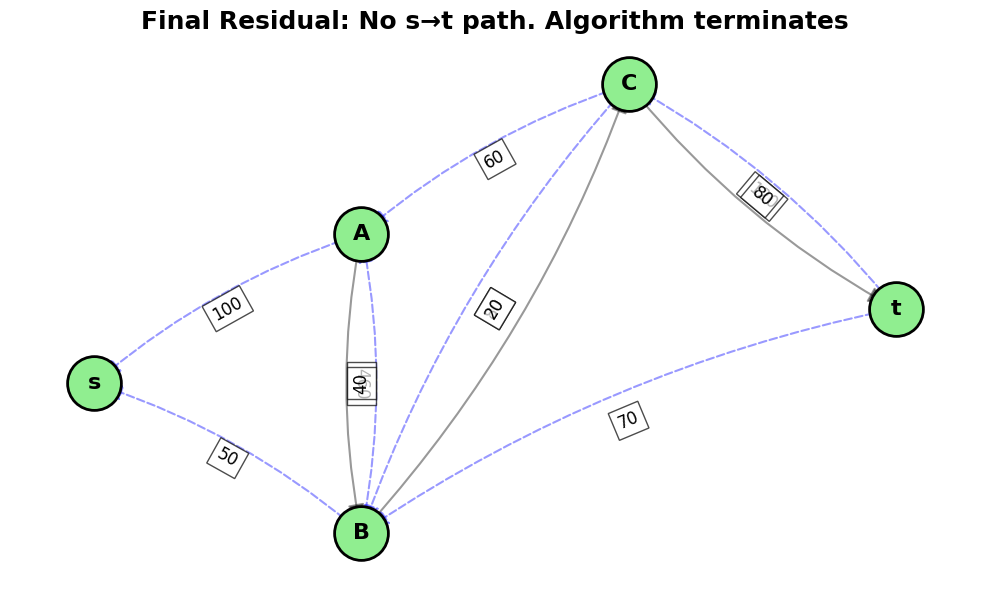

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

def dfs_find_path(residual_graph, u, t, visited, parent):
    """DFS to find any augmenting path in G_f."""
    if u == t:
        return True

    visited.add(u)

    for v, cap in residual_graph[u].items():
        if v not in visited and cap > 0:
            parent[v] = u
            if dfs_find_path(residual_graph, v, t, visited, parent):
                return True
    return False

# In the main loop, you would call it like this:
# parent = {}
# while dfs_find_path(residual, s, t, set(), parent):
#     ... same augmentation logic ...

def ford_fulkerson(edges, s='s', t='t'):
    flows = {edge: 0 for edge in edges}
    residual = {}
    nodes = set([u for u, v in edges] + [v for u, v in edges])

    for u in nodes:
        residual[u] = {}
    for (u, v), cap in edges.items():
        residual[u][v] = cap
        if v not in residual[u]: # Ensure reverse edges exist in dict
            residual[u][v] = cap
        if u not in residual[v]:
            residual[v][u] = 0

    max_flow = 0
    steps = [(flows.copy(), f"Initial: |f| = 0")]

    # --- THE FIX IS HERE ---
    while True:
        parent = {}
        visited = set()
        # Call DFS with the correct number of arguments
        if not dfs_find_path(residual, s, t, visited, parent):
            break

        # Find bottleneck
        path_flow = float('inf')
        v = t
        path_nodes = [t]
        while v != s:
            u = parent[v]
            path_flow = min(path_flow, residual[u][v])
            v = u
            path_nodes.append(v)
        path_nodes.reverse()

        # Update residual capacities and flow dict
        v = t
        while v != s:
            u = parent[v]
            residual[u][v] -= path_flow
            residual[v][u] += path_flow

            if (u, v) in flows:
                flows[(u, v)] += path_flow
            else:
                flows[(v, u)] -= path_flow
            v = u

        max_flow += path_flow
        steps.append((flows.copy(), f"Augmented by {path_flow}. |f| = {max_flow}"))
        steps.append((flows.copy(), path_nodes))

    return flows, max_flow, steps

def draw_flow_network(edges, flows, pos=None, title="Flow Network"):
    G = nx.DiGraph()
    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        G.add_edge(u, v, capacity=cap, flow=flow, label=f'{flow}/{cap}')

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                           node_size=1500, edgecolors='black', linewidths=2)

    saturated = [(u, v) for u, v, d in G.edges(data=True)
                 if d['flow'] == d['capacity'] and d['capacity'] > 0]
    normal = [(u, v) for u, v, d in G.edges(data=True)
              if d['flow'] < d['capacity']]

    nx.draw_networkx_edges(G, pos, edgelist=normal, arrowsize=25,
                           width=2, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(G, pos, edgelist=saturated, edge_color='red',
                           arrowsize=25, style='dashed', width=2,
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def draw_residual_network(edges, flows, pos=None, title="Residual Network", highlight_path=None):
    Gf = nx.DiGraph()
    for (u, v), cap in edges.items():
        flow = flows.get((u, v), 0)
        residual = cap - flow
        if residual > 0:
            Gf.add_edge(u, v, residual=residual, label=str(residual), kind='forward')

    for (u, v), flow in flows.items():
        if flow > 0:
            Gf.add_edge(v, u, residual=flow, label=str(flow), kind='backward')

    if pos is None:
        pos = nx.spring_layout(Gf, seed=42)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(Gf, pos, node_color='lightgreen',
                           node_size=1500, edgecolors='black', linewidths=2)

    if highlight_path:
        nx.draw_networkx_nodes(Gf, pos, nodelist=highlight_path,
                               node_color='orange', node_size=1500,
                               edgecolors='black', linewidths=2)
        path_edges = list(zip(highlight_path, highlight_path[1:]))
    else:
        path_edges = []

    forward = [(u, v) for u, v, d in Gf.edges(data=True)
               if d['kind'] == 'forward' and (u, v) not in path_edges]
    backward = [(u, v) for u, v, d in Gf.edges(data=True)
                if d['kind'] == 'backward' and (u, v) not in path_edges]

    nx.draw_networkx_edges(Gf, pos, edgelist=forward, arrowsize=25,
                           width=1.5, alpha=0.4, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=backward, arrowsize=25,
                           style='dashed', edge_color='blue', width=1.5,
                           alpha=0.4, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edges(Gf, pos, edgelist=path_edges, arrowsize=25,
                           width=4, edge_color='orange',
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(Gf, pos, font_size=16, font_weight='bold')
    edge_labels = nx.get_edge_attributes(Gf, 'label')
    nx.draw_networkx_edge_labels(Gf, pos, edge_labels, font_size=12,
                                 bbox=dict(alpha=0.7, facecolor='white'))

    plt.title(title, fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":

    edges = {
        ('s', 'A'): 100,
        ('s', 'B'): 50,
        ('A', 'C'): 60,
        ('A', 'B'): 500,
        ('B', 't'): 70,
        ('C', 't'): 200,
        ('B', 'C'): 100
        # change edges' details and add more edges, or remove existing edges as needed
    }
    pos = {'s': (0, 0), 'A': (1, 1), 'B': (1, -1), 'C': (2, 2), 't': (3, .5)}
    # change pos dictionary values depending on the edges chosen, so that the graph looks legible.

    final_flows, max_flow, steps = ford_fulkerson(edges, 's', 't')

    print(f"Max flow = {max_flow}")

    # Draw every step
    for i, step in enumerate(steps):
        if isinstance(step[1], str): # it's a flow state with title
            flows, title = step
            draw_flow_network(edges, flows, pos, title)
        else: # it's a path to highlight
            flows, path = step
            draw_residual_network(edges, flows, pos,
                                  f"Augmenting path: {' → '.join(path)}",
                                  highlight_path=path)

    # Final residual network
    draw_residual_network(edges, final_flows, pos,
                          "Final Residual: No s→t path. Algorithm terminates")